In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import json
import pickle
import numpy as np
import cv2
from tqdm import tqdm
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models.detection.mask_rcnn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ── Dataset paths ──────────────────────────────────────────────────────────────
DATA_ROOT = "/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2"

train_img_folder = DATA_ROOT + "/train/image"
val_img_folder   = DATA_ROOT + "/validation/image"
train_json_folder = DATA_ROOT + "/train/annos"
val_json_folder   = DATA_ROOT + "/validation/annos"

# ── Pre-processed path lists (image paths only) ────────────────────────────────
TRAIN_PKL = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed/train_data.pkl"
VAL_PKL   = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed-val/validation_data.pkl"

# ── Output ─────────────────────────────────────────────────────────────────────
SAVE_PATH = "/kaggle/working/best_maskrcnn.pth"

In [3]:
with open(TRAIN_PKL, "rb") as f:
    train_paths, _ = pickle.load(f)

with open(VAL_PKL, "rb") as f:
    val_paths, _ = pickle.load(f)

print(f"Total train images: {len(train_paths)}")
print(f"Total val images  : {len(val_paths)}")
print("Sample train path :", train_paths[0])

Total train images: 144174
Total val images  : 23741
Sample train path : /kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2/train/image/039350.jpg


In [4]:
# Top-5 most frequent categories in DeepFashion2
# 1=short sleeve top, 2=long sleeve top, 7=shorts, 8=trousers, 9=skirt
top5_ids = [1, 8, 7, 2, 9]

category_to_index = {cat: i for i, cat in enumerate(top5_ids)}

# Human-readable names aligned to model label indices 1..5  (0 = background)
IDX_TO_NAME = {
    0: "background",
    1: "short_sleeve_top",
    2: "trousers",
    3: "shorts",
    4: "long_sleeve_top",
    5: "skirt",
}

NUM_CLASSES = 6   # 5 clothing + 1 background
print("category_to_index:", category_to_index)
print("idx_to_name      :", IDX_TO_NAME)

category_to_index: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
idx_to_name      : {0: 'background', 1: 'short_sleeve_top', 2: 'trousers', 3: 'shorts', 4: 'long_sleeve_top', 5: 'skirt'}


In [5]:
def parse_annotation(json_path):
    """
    Parse a DeepFashion2 JSON annotation file.
    Returns boxes, labels (1-indexed for Mask R-CNN), and raw polygon segmentations.
    """
    with open(json_path) as f:
        data = json.load(f)

    boxes, labels, masks = [], [], []

    for key in data:
        if not key.startswith("item"):
            continue

        cid = data[key]["category_id"]
        if cid not in category_to_index:
            continue

        x1, y1, x2, y2 = data[key]["bounding_box"]

        # Skip degenerate boxes
        if x2 <= x1 or y2 <= y1:
            continue

        seg = data[key]["segmentation"]

        boxes.append([x1, y1, x2, y2])
        labels.append(category_to_index[cid] + 1)   # +1 because 0 is background
        masks.append(seg)

    return boxes, labels, masks

In [6]:
def polygons_to_mask(polygons, height, width):
    """
    Convert a list of polygon coordinate lists into a binary uint8 mask.
    Each polygon is [x1, y1, x2, y2, ...] flattened.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

In [7]:
class DetectionDataset(Dataset):
    """
    PyTorch Dataset for Mask R-CNN on DeepFashion2.
    Returns (image_tensor, target_dict) pairs.
    """

    def __init__(self, image_paths, json_folder):
        self.image_paths = image_paths
        self.json_folder  = json_folder

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        image     = Image.open(img_path).convert("RGB")

        json_name = os.path.basename(img_path).replace(".jpg", ".json")
        json_path = os.path.join(self.json_folder, json_name)

        boxes, labels, segmentations = parse_annotation(json_path)

        # Skip images with no valid annotations
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.image_paths))

        width, height = image.size

        # Convert polygon segmentations to binary masks
        masks = []
        for seg in segmentations:
            mask = polygons_to_mask(seg, height, width)
            masks.append(mask)

        masks = torch.tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes" : torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "masks" : masks,
        }

        return F.to_tensor(image), target


def collate_fn(batch):
    return tuple(zip(*batch))

In [8]:
# Adjust subset sizes based on available compute
TRAIN_SIZE = 5000
VAL_SIZE   = 2000
BATCH_SIZE = 4

train_dataset = DetectionDataset(train_paths[:TRAIN_SIZE], train_json_folder)
val_dataset   = DetectionDataset(val_paths[:VAL_SIZE],   val_json_folder)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 1250
Val   batches: 500


In [9]:
# ── Load pretrained backbone ───────────────────────────────────────────────────
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.COCO_V1
)

# ── Replace box predictor ──────────────────────────────────────────────────────
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, NUM_CLASSES
    )

# ── Replace mask predictor ─────────────────────────────────────────────────────
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask,
        256,           # hidden dimension
        NUM_CLASSES
    )

model = model.to(device)
print("Model ready on", device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 225MB/s] 


Model ready on cuda


From scratch -


In [20]:
# ── Train from scratch (randomly initialized weights) ─────────────────────────
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

# ── Replace box predictor ──────────────────────────────────────────────────────
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, NUM_CLASSES
    )

# ── Replace mask predictor ─────────────────────────────────────────────────────
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask,
        256,
        NUM_CLASSES
    )

model = model.to(device)
print("Model ready (from scratch) on", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Model ready (from scratch) on cuda


In [ ]:
EPOCHS = 10
best_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Training phase ─────────────────────────────────────────────────────────
    model.train()
    total_loss      = 0
    total_cls_loss  = 0
    total_box_loss  = 0
    total_mask_loss = 0
    total_obj_loss  = 0
    total_rpn_loss  = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):

        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss      += loss.item()
        total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
        total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
        total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
        total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
        total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    n = len(train_loader)
    avg_loss      = total_loss      / n
    avg_cls_loss  = total_cls_loss  / n
    avg_box_loss  = total_box_loss  / n
    avg_mask_loss = total_mask_loss / n
    avg_obj_loss  = total_obj_loss  / n
    avg_rpn_loss  = total_rpn_loss  / n

    # ── Validation phase ────────────────────────────────────────────────────────
    model.train()   # Mask R-CNN needs train() mode to compute losses on val too
    val_total_loss      = 0
    val_total_cls_loss  = 0
    val_total_box_loss  = 0
    val_total_mask_loss = 0
    val_total_obj_loss  = 0
    val_total_rpn_loss  = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):

            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            val_total_loss      += sum(loss_dict.values()).item()
            val_total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
            val_total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
            val_total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
            val_total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
            val_total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    m = len(val_loader)
    val_avg_loss      = val_total_loss      / m
    val_avg_cls_loss  = val_total_cls_loss  / m
    val_avg_box_loss  = val_total_box_loss  / m
    val_avg_mask_loss = val_total_mask_loss / m
    val_avg_obj_loss  = val_total_obj_loss  / m
    val_avg_rpn_loss  = val_total_rpn_loss  / m

    # ── Print comparison ────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*65}")
    print(f"{'Loss':<25} {'Train':>10} {'Val':>10} {'Diff':>10}")
    print(f"{'-'*65}")
    print(f"{'Total Loss':<25} {avg_loss:>10.4f} {val_avg_loss:>10.4f} {val_avg_loss - avg_loss:>+10.4f}")
    print(f"{'Classifier Loss':<25} {avg_cls_loss:>10.4f} {val_avg_cls_loss:>10.4f} {val_avg_cls_loss - avg_cls_loss:>+10.4f}")
    print(f"{'Box Reg Loss':<25} {avg_box_loss:>10.4f} {val_avg_box_loss:>10.4f} {val_avg_box_loss - avg_box_loss:>+10.4f}")
    print(f"{'Mask Loss':<25} {avg_mask_loss:>10.4f} {val_avg_mask_loss:>10.4f} {val_avg_mask_loss - avg_mask_loss:>+10.4f}")
    print(f"{'Objectness Loss':<25} {avg_obj_loss:>10.4f} {val_avg_obj_loss:>10.4f} {val_avg_obj_loss - avg_obj_loss:>+10.4f}")
    print(f"{'RPN Box Loss':<25} {avg_rpn_loss:>10.4f} {val_avg_rpn_loss:>10.4f} {val_avg_rpn_loss - avg_rpn_loss:>+10.4f}")
    print(f"{'-'*65}")

    # Overfitting warning
    if val_avg_loss - avg_loss > 0.15:
        print("  ⚠️  Warning: possible overfitting (val >> train loss)")
    elif val_avg_loss < avg_loss:
        print("  ✅ Val loss lower than train loss — generalizing well")
    else:
        print("  ℹ️  Val loss close to train loss — healthy training")

    # ── Save best model (based on val loss) ────────────────────────────────────
    if val_avg_loss < best_loss:
        best_loss = val_avg_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print("  💾 Best model saved!")

print(f"\nTraining complete. Best Val Loss: {round(best_loss, 4)}")

In [ ]:
from torchvision.ops import box_iou

# ── Load best model for evaluation ────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Thresholds
DET_SCORE_THRESH = 0.5    # confidence threshold for detections
IOU_THRESH       = 0.5    # IoU threshold for a "match" in detection
MASK_THRESH      = 0.5    # sigmoid threshold to binarize predicted masks

# Per-class accumulators  (index 1..5 = clothing classes)
tp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fn_det  = {i: 0 for i in range(1, NUM_CLASSES)}

iou_sum_seg  = {i: 0.0 for i in range(1, NUM_CLASSES)}
dice_sum_seg = {i: 0.0 for i in range(1, NUM_CLASSES)}
seg_count    = {i: 0   for i in range(1, NUM_CLASSES)}

print("Running evaluation on validation set...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):

        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()     # (N, 1, H, W) — probabilities

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks  = tgt["masks"]             # (M, H, W) — binary uint8

            # Filter by score
            keep = pred_scores >= DET_SCORE_THRESH
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_masks  = pred_masks[keep]

            # ── Detection metric (TP / FP / FN per class) ─────────────────────
            gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)  # (P, G)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]             # (G,)

                    # Only consider GT of same class
                    same_cls = (gt_labels == p_cls).numpy()
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~torch.tensor(same_cls)] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched[best_j]:
                        tp_det[p_cls] = tp_det.get(p_cls, 0) + 1
                        gt_matched[best_j] = True
                    else:
                        fp_det[p_cls] = fp_det.get(p_cls, 0) + 1

            # Unmatched GT = false negatives
            for g_idx in range(len(gt_boxes)):
                if not gt_matched[g_idx]:
                    g_cls = gt_labels[g_idx].item()
                    fn_det[g_cls] = fn_det.get(g_cls, 0) + 1

            # ── Segmentation metric (mIoU, Dice per matched instance) ──────────
            gt_matched2 = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]
                    same_cls = (gt_labels == p_cls)
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~same_cls] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched2[best_j]:
                        gt_matched2[best_j] = True

                        # Binarize predicted mask
                        p_mask = (pred_masks[p_idx, 0] >= MASK_THRESH).numpy().astype(np.uint8)
                        g_mask = gt_masks[best_j].numpy().astype(np.uint8)

                        # Resize pred mask to match GT if needed
                        if p_mask.shape != g_mask.shape:
                            p_mask = cv2.resize(p_mask, (g_mask.shape[1], g_mask.shape[0]),
                                                interpolation=cv2.INTER_NEAREST)

                        intersection = np.logical_and(p_mask, g_mask).sum()
                        union        = np.logical_or(p_mask,  g_mask).sum()
                        p_sum        = p_mask.sum()
                        g_sum        = g_mask.sum()

                        iou_val  = intersection / (union + 1e-6)
                        dice_val = 2 * intersection / (p_sum + g_sum + 1e-6)

                        iou_sum_seg[p_cls]  += iou_val
                        dice_sum_seg[p_cls] += dice_val
                        seg_count[p_cls]    += 1

print("\nEvaluation complete.")

Done

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [15]:
EPOCHS = 10
best_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Training phase ─────────────────────────────────────────────────────────
    model.train()
    total_loss      = 0
    total_cls_loss  = 0
    total_box_loss  = 0
    total_mask_loss = 0
    total_obj_loss  = 0
    total_rpn_loss  = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):

        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss      += loss.item()
        total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
        total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
        total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
        total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
        total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    n = len(train_loader)
    avg_loss      = total_loss      / n
    avg_cls_loss  = total_cls_loss  / n
    avg_box_loss  = total_box_loss  / n
    avg_mask_loss = total_mask_loss / n
    avg_obj_loss  = total_obj_loss  / n
    avg_rpn_loss  = total_rpn_loss  / n

    # ── Validation phase ────────────────────────────────────────────────────────
    model.train()   # Mask R-CNN needs train() mode to compute losses on val too
    val_total_loss      = 0
    val_total_cls_loss  = 0
    val_total_box_loss  = 0
    val_total_mask_loss = 0
    val_total_obj_loss  = 0
    val_total_rpn_loss  = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):

            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            val_total_loss      += sum(loss_dict.values()).item()
            val_total_cls_loss  += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
            val_total_box_loss  += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
            val_total_mask_loss += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
            val_total_obj_loss  += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
            val_total_rpn_loss  += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    m = len(val_loader)
    val_avg_loss      = val_total_loss      / m
    val_avg_cls_loss  = val_total_cls_loss  / m
    val_avg_box_loss  = val_total_box_loss  / m
    val_avg_mask_loss = val_total_mask_loss / m
    val_avg_obj_loss  = val_total_obj_loss  / m
    val_avg_rpn_loss  = val_total_rpn_loss  / m

    # ── Print comparison ────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*65}")
    print(f"{'Loss':<25} {'Train':>10} {'Val':>10} {'Diff':>10}")
    print(f"{'-'*65}")
    print(f"{'Total Loss':<25} {avg_loss:>10.4f} {val_avg_loss:>10.4f} {val_avg_loss - avg_loss:>+10.4f}")
    print(f"{'Classifier Loss':<25} {avg_cls_loss:>10.4f} {val_avg_cls_loss:>10.4f} {val_avg_cls_loss - avg_cls_loss:>+10.4f}")
    print(f"{'Box Reg Loss':<25} {avg_box_loss:>10.4f} {val_avg_box_loss:>10.4f} {val_avg_box_loss - avg_box_loss:>+10.4f}")
    print(f"{'Mask Loss':<25} {avg_mask_loss:>10.4f} {val_avg_mask_loss:>10.4f} {val_avg_mask_loss - avg_mask_loss:>+10.4f}")
    print(f"{'Objectness Loss':<25} {avg_obj_loss:>10.4f} {val_avg_obj_loss:>10.4f} {val_avg_obj_loss - avg_obj_loss:>+10.4f}")
    print(f"{'RPN Box Loss':<25} {avg_rpn_loss:>10.4f} {val_avg_rpn_loss:>10.4f} {val_avg_rpn_loss - avg_rpn_loss:>+10.4f}")
    print(f"{'-'*65}")

    # Overfitting warning
    if val_avg_loss - avg_loss > 0.15:
        print("  ⚠️  Warning: possible overfitting (val >> train loss)")
    elif val_avg_loss < avg_loss:
        print("  ✅ Val loss lower than train loss — generalizing well")
    else:
        print("  ℹ️  Val loss close to train loss — healthy training")

    # ── Save best model (based on val loss) ────────────────────────────────────
    if val_avg_loss < best_loss:
        best_loss = val_avg_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print("  💾 Best model saved!")

print(f"\nTraining complete. Best Val Loss: {round(best_loss, 4)}")

Epoch 1/10 [Val]: 100%|██████████| 500/500 [06:06<00:00,  1.36it/s]



Epoch 1/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.4241     0.4341    +0.0101
Classifier Loss               0.0965     0.0977    +0.0012
Box Reg Loss                  0.0987     0.1027    +0.0040
Mask Loss                     0.2146     0.2192    +0.0046
Objectness Loss               0.0043     0.0046    +0.0004
RPN Box Loss                  0.0100     0.0099    -0.0001
-----------------------------------------------------------------
  ℹ️  Val loss close to train loss — healthy training
  💾 Best model saved!


Epoch 2/10 [Val]: 100%|██████████| 500/500 [06:07<00:00,  1.36it/s]



Epoch 2/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.3597     0.4060    +0.0463
Classifier Loss               0.0788     0.0905    +0.0116
Box Reg Loss                  0.0848     0.0964    +0.0116
Mask Loss                     0.1837     0.2045    +0.0208
Objectness Loss               0.0033     0.0047    +0.0013
RPN Box Loss                  0.0091     0.0101    +0.0010
-----------------------------------------------------------------
  ℹ️  Val loss close to train loss — healthy training
  💾 Best model saved!


Epoch 3/10 [Val]: 100%|██████████| 500/500 [06:06<00:00,  1.36it/s]


...


Epoch 8/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.2167     0.3800    +0.1633
Classifier Loss               0.0366     0.0850    +0.0484
Box Reg Loss                  0.0503     0.0812    +0.0309
Mask Loss                     0.1214     0.1987    +0.0774
Objectness Loss               0.0013     0.0058    +0.0045
RPN Box Loss                  0.0072     0.0092    +0.0021
-----------------------------------------------------------------
  ⚠️  Warning: possible overfitting (val >> train loss)


Epoch 9/10 [Val]: 100%|██████████| 500/500 [06:07<00:00,  1.36it/s]



Epoch 9/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.2019     0.3951    +0.1932
Classifier Loss               0.0318     0.0969    +0.0652
Box Reg Loss                  0.0465     0.0797    +0.0332
Mask Loss                     0.1157     0.2024    +0.0867
Objectness Loss               0.0012     0.0072    +0.0061
RPN Box Loss                  0.0068     0.0089    +0.0021
-----------------------------------------------------------------
  ⚠️  Warning: possible overfitting (val >> train loss)


Epoch 10/10 [Val]: 100%|██████████| 500/500 [06:08<00:00,  1.36it/s]


Epoch 10/10
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total Loss                    0.1942     0.4134    +0.2192
Classifier Loss               0.0305     0.1108    +0.0803
Box Reg Loss                  0.0451     0.0838    +0.0387
Mask Loss                     0.1107     0.2020    +0.0913
Objectness Loss               0.0011     0.0077    +0.0066
RPN Box Loss                  0.0067     0.0090    +0.0023
-----------------------------------------------------------------
  ⚠️  Warning: possible overfitting (val >> train loss)

Training complete. Best Val Loss: 0.3634


In [16]:
from torchvision.ops import box_iou

# ── Load best model for evaluation ────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Thresholds
DET_SCORE_THRESH = 0.5    # confidence threshold for detections
IOU_THRESH       = 0.5    # IoU threshold for a "match" in detection
MASK_THRESH      = 0.5    # sigmoid threshold to binarize predicted masks

# Per-class accumulators  (index 1..5 = clothing classes)
tp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fp_det  = {i: 0 for i in range(1, NUM_CLASSES)}
fn_det  = {i: 0 for i in range(1, NUM_CLASSES)}

iou_sum_seg  = {i: 0.0 for i in range(1, NUM_CLASSES)}
dice_sum_seg = {i: 0.0 for i in range(1, NUM_CLASSES)}
seg_count    = {i: 0   for i in range(1, NUM_CLASSES)}

print("Running evaluation on validation set...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):

        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()     # (N, 1, H, W) — probabilities

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks  = tgt["masks"]             # (M, H, W) — binary uint8

            # Filter by score
            keep = pred_scores >= DET_SCORE_THRESH
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_masks  = pred_masks[keep]

            # ── Detection metric (TP / FP / FN per class) ─────────────────────
            gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)  # (P, G)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]             # (G,)

                    # Only consider GT of same class
                    same_cls = (gt_labels == p_cls).numpy()
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~torch.tensor(same_cls)] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched[best_j]:
                        tp_det[p_cls] = tp_det.get(p_cls, 0) + 1
                        gt_matched[best_j] = True
                    else:
                        fp_det[p_cls] = fp_det.get(p_cls, 0) + 1

            # Unmatched GT = false negatives
            for g_idx in range(len(gt_boxes)):
                if not gt_matched[g_idx]:
                    g_cls = gt_labels[g_idx].item()
                    fn_det[g_cls] = fn_det.get(g_cls, 0) + 1

            # ── Segmentation metric (mIoU, Dice per matched instance) ──────────
            gt_matched2 = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                for p_idx in range(len(pred_boxes)):
                    p_cls = pred_labels[p_idx].item()
                    iou_row = iou_matrix[p_idx]
                    same_cls = (gt_labels == p_cls)
                    iou_row_masked = iou_row.clone()
                    iou_row_masked[~same_cls] = 0

                    best_iou, best_j = iou_row_masked.max(0) if len(iou_row_masked) > 0 \
                                       else (torch.tensor(0.), torch.tensor(0))

                    if best_iou >= IOU_THRESH and not gt_matched2[best_j]:
                        gt_matched2[best_j] = True

                        # Binarize predicted mask
                        p_mask = (pred_masks[p_idx, 0] >= MASK_THRESH).numpy().astype(np.uint8)
                        g_mask = gt_masks[best_j].numpy().astype(np.uint8)

                        # Resize pred mask to match GT if needed
                        if p_mask.shape != g_mask.shape:
                            p_mask = cv2.resize(p_mask, (g_mask.shape[1], g_mask.shape[0]),
                                                interpolation=cv2.INTER_NEAREST)

                        intersection = np.logical_and(p_mask, g_mask).sum()
                        union        = np.logical_or(p_mask,  g_mask).sum()
                        p_sum        = p_mask.sum()
                        g_sum        = g_mask.sum()

                        iou_val  = intersection / (union + 1e-6)
                        dice_val = 2 * intersection / (p_sum + g_sum + 1e-6)

                        iou_sum_seg[p_cls]  += iou_val
                        dice_sum_seg[p_cls] += dice_val
                        seg_count[p_cls]    += 1

print("\nEvaluation complete.")

Running evaluation on validation set...


Evaluating: 100%|██████████| 500/500 [06:16<00:00,  1.33it/s]


Evaluation complete.


In [17]:
print("=" * 70)
print("DETECTION RESULTS  (IoU threshold = 0.5)")
print("=" * 70)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 70)

macro_precisions, macro_recalls, macro_f1s = [], [], []

for cls_id in range(1, NUM_CLASSES):
    tp = tp_det[cls_id]
    fp = fp_det[cls_id]
    fn = fn_det[cls_id]

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    macro_precisions.append(precision)
    macro_recalls.append(recall)
    macro_f1s.append(f1)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(macro_precisions):>10.4f} "
      f"{np.mean(macro_recalls):>10.4f} {np.mean(macro_f1s):>10.4f}")

all_tp = sum(tp_det.values())
all_fp = sum(fp_det.values())
all_fn = sum(fn_det.values())
micro_p  = all_tp / (all_tp + all_fp + 1e-6)
micro_r  = all_tp / (all_tp + all_fn + 1e-6)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-6)
print(f"  {'Micro Average':<20} {micro_p:>10.4f} {micro_r:>10.4f} {micro_f1:>10.4f}")

print()
print("=" * 70)
print("SEGMENTATION RESULTS")
print("=" * 70)
print(f"{'Class':<22} {'mIoU':>10} {'Dice':>10} {'Instances':>10}")
print("-" * 70)

all_ious, all_dices = [], []

for cls_id in range(1, NUM_CLASSES):
    cnt = seg_count[cls_id]
    if cnt > 0:
        class_iou  = iou_sum_seg[cls_id]  / cnt
        class_dice = dice_sum_seg[cls_id] / cnt
    else:
        class_iou = class_dice = 0.0

    all_ious.append(class_iou)
    all_dices.append(class_dice)

    name = IDX_TO_NAME.get(cls_id, f"class_{cls_id}")
    print(f"  {name:<20} {class_iou:>10.4f} {class_dice:>10.4f} {cnt:>10}")

print("-" * 70)
print(f"  {'Macro Average':<20} {np.mean(all_ious):>10.4f} {np.mean(all_dices):>10.4f}")
print("=" * 70)

DETECTION RESULTS  (IoU threshold = 0.5)
Class                   Precision     Recall         F1     TP     FP     FN
----------------------------------------------------------------------
  short_sleeve_top         0.6202     0.9601     0.7536   1060    649     44
  trousers                 0.6781     0.9259     0.7829    750    356     60
  shorts                   0.4845     0.8296     0.6117    297    316     61
  long_sleeve_top          0.6063     0.7041     0.6516    345    224    145
  skirt                    0.6235     0.8008     0.7011    414    250    103
----------------------------------------------------------------------
  Macro Average            0.6025     0.8441     0.7002
  Micro Average            0.6149     0.8740     0.7219

SEGMENTATION RESULTS
Class                        mIoU       Dice  Instances
----------------------------------------------------------------------
  short_sleeve_top         0.8860     0.9371       1060
  trousers                 0.8445     

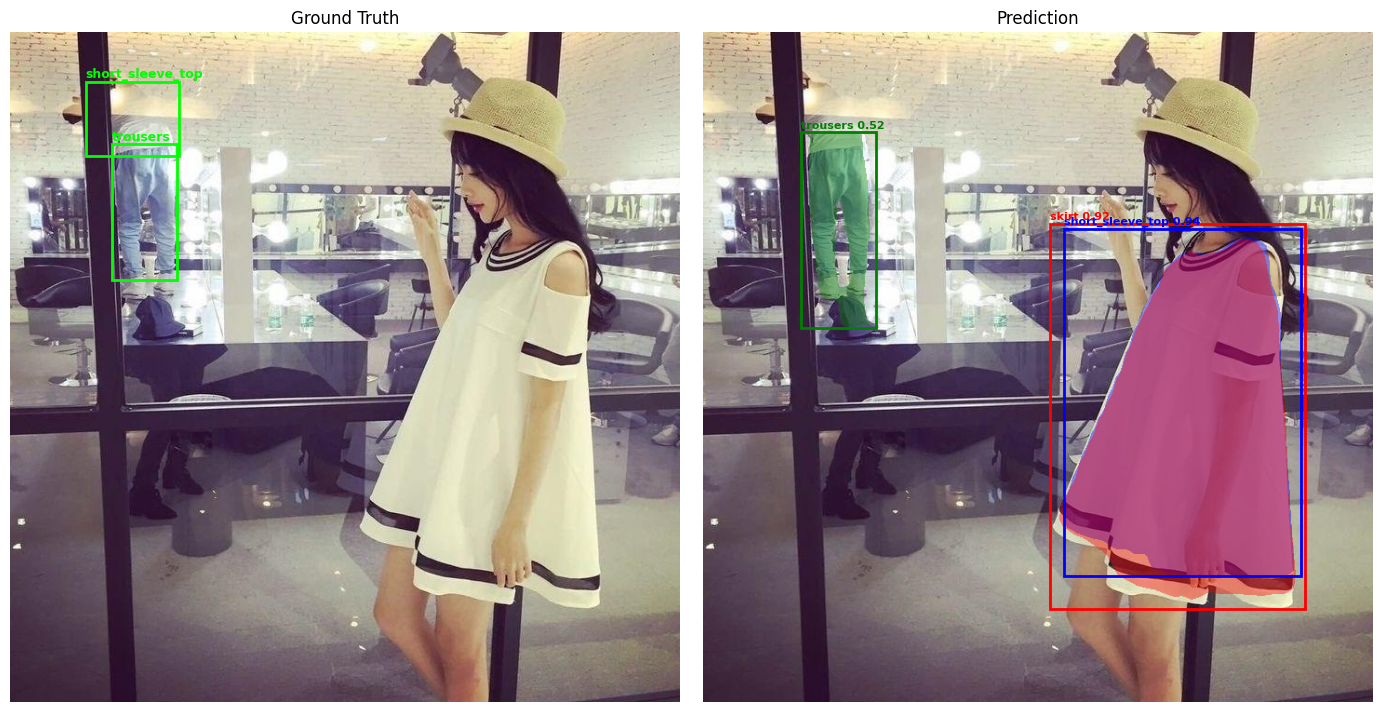

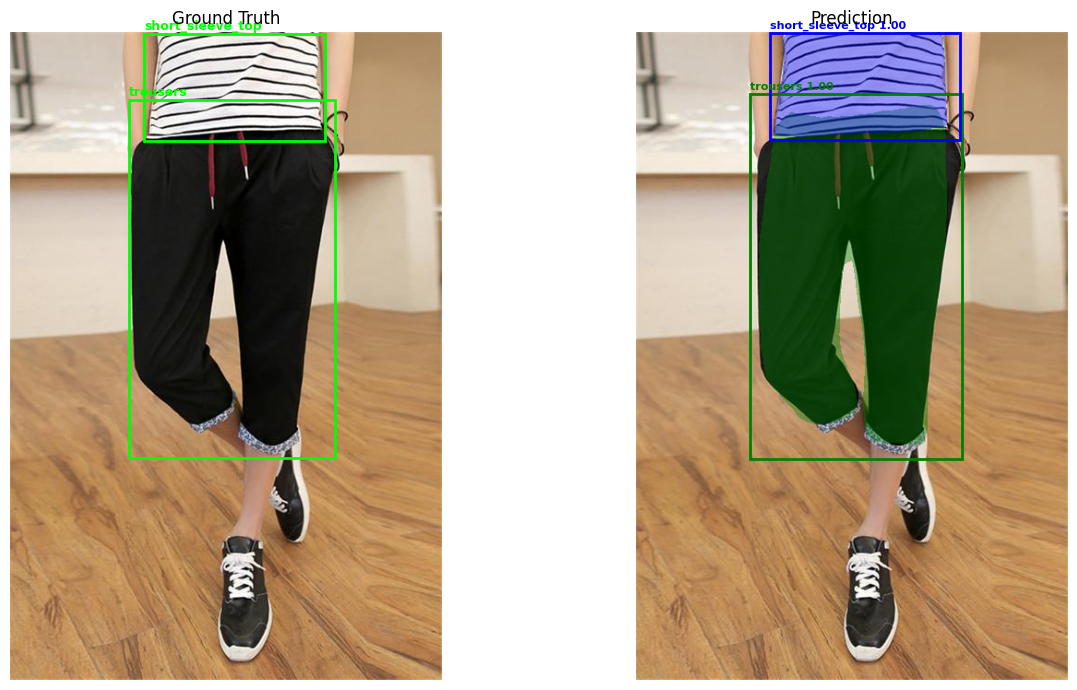

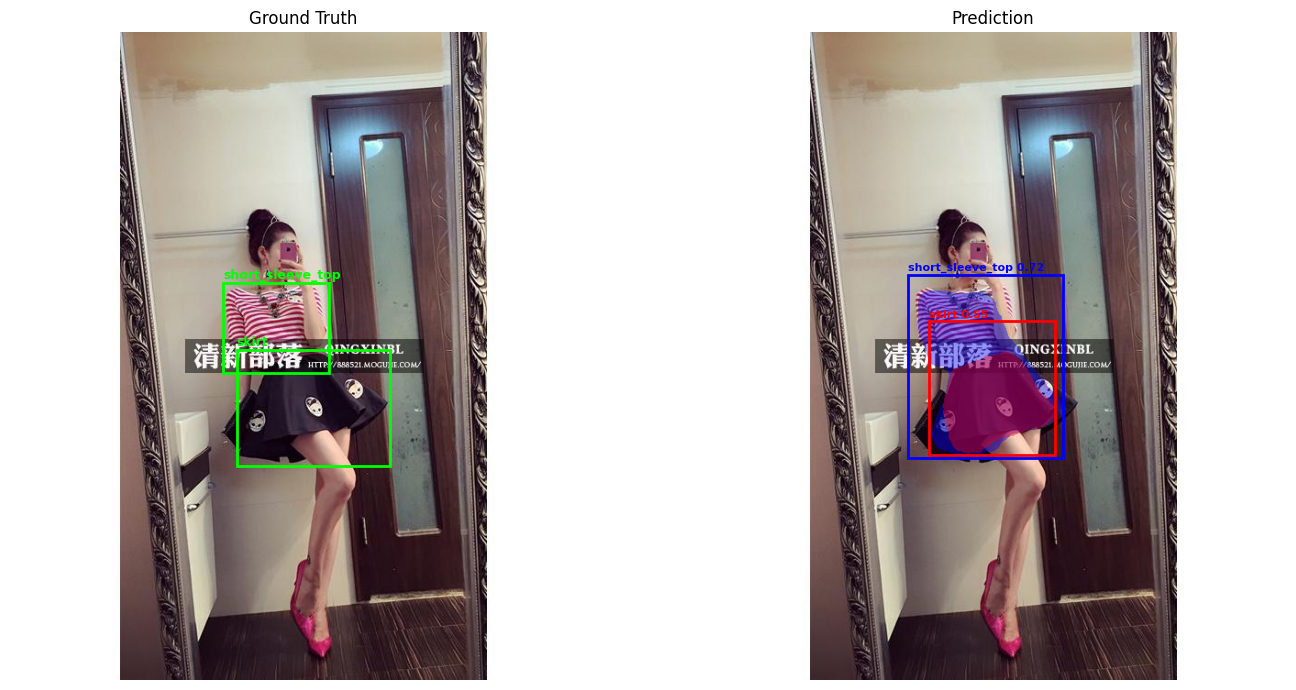

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import random

COLORS = ["red", "blue", "green", "orange", "purple"]

def visualize_prediction(model, dataset, idx=None, score_thresh=0.5):
    model.eval()
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_tensor, target = dataset[idx]
    image_np = img_tensor.permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]

    pred_boxes  = output["boxes"].cpu().numpy()
    pred_scores = output["scores"].cpu().numpy()
    pred_labels = output["labels"].cpu().numpy()
    pred_masks  = output["masks"].cpu().numpy()    # (N, 1, H, W)

    keep = pred_scores >= score_thresh
    pred_boxes  = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_masks  = pred_masks[keep]
    pred_scores = pred_scores[keep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Ground truth
    axes[0].imshow(image_np)
    axes[0].set_title("Ground Truth")
    for box, lbl in zip(target["boxes"].numpy(), target["labels"].numpy()):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 4, IDX_TO_NAME.get(lbl, str(lbl)),
                     color="lime", fontsize=9, fontweight="bold")
    axes[0].axis("off")

    # Predictions
    overlay = image_np.copy()
    axes[1].imshow(overlay)
    axes[1].set_title("Prediction")
    for i, (box, lbl, score, mask) in enumerate(
            zip(pred_boxes, pred_labels, pred_scores, pred_masks)):
        x1, y1, x2, y2 = box
        color = COLORS[lbl % len(COLORS)]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 4,
                     f"{IDX_TO_NAME.get(lbl, str(lbl))} {score:.2f}",
                     color=color, fontsize=8, fontweight="bold")

        # Overlay mask
        binary_mask = (mask[0] >= MASK_THRESH).astype(np.float32)
        rgba = np.zeros((*binary_mask.shape, 4))
        r, g, b, _ = to_rgba(color)
        rgba[..., 0] = r
        rgba[..., 1] = g
        rgba[..., 2] = b
        rgba[..., 3] = binary_mask * 0.4
        axes[1].imshow(rgba)

    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Visualize a few samples
for _ in range(3):
    visualize_prediction(model, val_dataset, score_thresh=0.5)

In [19]:
torch.save(model.state_dict(), "/kaggle/working/maskrcnn_final.pth")
print("Final model saved to /kaggle/working/maskrcnn_final.pth")
print("Best model (lowest train loss) saved to", SAVE_PATH)

Final model saved to /kaggle/working/maskrcnn_final.pth
Best model (lowest train loss) saved to /kaggle/working/best_maskrcnn.pth
